# MS-ConvGRU v1 — Multi-Scale Conv1D-GRU with Dual Attention

**Architecture:**
- Multi-Scale input branches (kernel 3, 5, 7) → captures temporal patterns at different scales
- Separable Conv1D blocks with residual connections
- ECA (Efficient Channel Attention) + Temporal Attention
- Bidirectional GRU for sequential modeling
- Prototype Network calibration + LogReg calibration for comparison

**Training Strategy:**
- Data augmentation: Gaussian noise, time shift, amplitude scaling, channel dropout
- AdamW optimizer with cosine annealing + warmup
- Label smoothing (0.1)

## Imports

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import time

from config import (
    RANDOM_SEED, N_CLASSES, N_CHANNELS, WINDOW_SIZE,
    MODELS_DIR, FIGURES_DIR, get_device,
    SUBJECTS_FATIGUE, SUBJECTS_NON_FATIGUE,
    SUBJECTS_INTERDAY_LONG, SUBJECTS_INTERDAY_SHORT,
    GESTURE_CLASSES,
)
from src.experiment_runner import (
    TEST_SUBJECTS, TRAIN_SUBJECTS, META, get_splits,
    load_and_norm, run_zero_shot, run_calibration, print_comparison,
)
from src.evaluation import measure_latency, print_latency

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")
print(f"Train subjects: {TRAIN_SUBJECTS}")
print(f"Test subjects:  {TEST_SUBJECTS}")

Device: mps
Train subjects: ['h0', 'h1', 'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h18', 'h19', 'h2', 'h20', 'h21', 'h23', 'h25', 'h26', 'h27', 'h28', 'h29', 'h4', 'h5', 'h6', 'h8', 'h9']
Test subjects:  ['h7', 'h22', 'h3', 'h24', 'h16', 'h17']


## Model Architecture

In [2]:
class ECA1d(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        import math
        k = int(abs(math.log2(channels) + b) / gamma)
        k = k if k % 2 else k + 1
        self.avg = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, k, padding=k // 2, bias=False)

    def forward(self, x):
        w = self.avg(x).transpose(-1, -2)
        w = torch.sigmoid(self.conv(w)).transpose(-1, -2)
        return x * w


class TemporalAttention(nn.Module):
    def __init__(self, seq_len):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(seq_len, seq_len // 2),
            nn.ReLU(),
            nn.Linear(seq_len // 2, seq_len),
            nn.Sigmoid(),
        )

    def forward(self, x):
        avg_pool = x.mean(dim=1)
        weights = self.fc(avg_pool).unsqueeze(1)
        return x * weights


class SepConv1d(nn.Module):
    def __init__(self, ic, oc, k, p=0):
        super().__init__()
        if p == 0:
            p = k // 2
        self.dw = nn.Conv1d(ic, ic, k, padding=p, groups=ic)
        self.pw = nn.Conv1d(ic, oc, 1)

    def forward(self, x):
        return self.pw(self.dw(x))


class MSConvGRU(nn.Module):
    def __init__(self, in_ch=N_CHANNELS, n_classes=N_CLASSES, seq_len=WINDOW_SIZE):
        super().__init__()

        self.branch3 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 3, padding=1), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch5 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch7 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU()
        )

        ms_out = 96
        self.eca_ms = ECA1d(ms_out)

        self.sep1 = SepConv1d(ms_out, 128, 5)
        self.bn1 = nn.BatchNorm1d(128)
        self.eca1 = ECA1d(128)
        self.res_proj1 = nn.Conv1d(ms_out, 128, 1) if ms_out != 128 else nn.Identity()

        self.sep2 = SepConv1d(128, 128, 3)
        self.bn2 = nn.BatchNorm1d(128)
        self.eca2 = ECA1d(128)

        self.temporal_attn = TemporalAttention(seq_len)

        self.gru = nn.GRU(128, 64, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        b7 = self.branch7(x)
        ms = torch.cat([b3, b5, b7], dim=1)
        ms = self.eca_ms(ms)

        res = self.res_proj1(ms)
        out = F.relu(self.bn1(self.sep1(ms)))
        out = self.eca1(out)
        out = out + res

        res2 = out
        out = F.relu(self.bn2(self.sep2(out)))
        out = self.eca2(out)
        out = out + res2

        out = self.temporal_attn(out)

        out = out.transpose(1, 2)
        out, _ = self.gru(out)
        out = out[:, -1, :]

        out = self.dropout(out)
        return self.fc(out)

    def extract_feat(self, x):
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        b7 = self.branch7(x)
        ms = torch.cat([b3, b5, b7], dim=1)
        ms = self.eca_ms(ms)
        res = self.res_proj1(ms)
        out = F.relu(self.bn1(self.sep1(ms)))
        out = self.eca1(out)
        out = out + res
        res2 = out
        out = F.relu(self.bn2(self.sep2(out)))
        out = self.eca2(out)
        out = out + res2
        out = self.temporal_attn(out)
        out = out.transpose(1, 2)
        out, _ = self.gru(out)
        out = out[:, -1, :]
        return out


model = MSConvGRU().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"MSConvGRU parameters: {total_params:,}")
print(model)

MSConvGRU parameters: 125,059
MSConvGRU(
  (branch3): Sequential(
    (0): Conv1d(8, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (branch5): Sequential(
    (0): Conv1d(8, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (branch7): Sequential(
    (0): Conv1d(8, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (eca_ms): ECA1d(
    (avg): AdaptiveAvgPool1d(output_size=1)
    (conv): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
  )
  (sep1): SepConv1d(
    (dw): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), groups=96)
    (pw): Conv1d(96, 128, kernel_size=(1,), stride=(1,))
  )
  (bn1): BatchNorm1d(128, eps=1e-05, mome

## Data Augmentation

In [3]:
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, augment=True):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]
        if self.augment:
            x = self._augment(x)
        return x, y

    def _augment(self, x):
        if np.random.random() < 0.5:
            noise = torch.randn_like(x) * 0.05 * x.std()
            x = x + noise
        if np.random.random() < 0.3:
            shift = np.random.randint(-3, 4)
            x = torch.roll(x, shifts=shift, dims=-1)
        if np.random.random() < 0.3:
            scale = 0.8 + np.random.random() * 0.4
            x = x * scale
        if np.random.random() < 0.1:
            ch = np.random.randint(0, x.shape[0])
            x[ch] = 0
        return x

## Train

In [4]:
splits = get_splits()
train_combined = pd.concat([splits["train_df"], splits["s5_train"]]).drop_duplicates()
X_train, y_train, norm_stats = load_and_norm(train_combined, verbose=True)
print(f"Training data: {X_train.shape}")

train_dataset = AugmentedDataset(X_train, y_train, augment=True)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

N_EPOCHS = 60
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

warmup_epochs = 5
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (N_EPOCHS - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_loss = float("inf")
best_state = None

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    scheduler.step()

    avg_loss = total_loss / total
    acc = correct / total
    lr_now = scheduler.get_last_lr()[0]

    if avg_loss < best_loss:
        best_loss = avg_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} — loss: {avg_loss:.4f}, acc: {acc:.4f}, lr: {lr_now:.6f}")

model.load_state_dict(best_state)
model.eval()
torch.save(model.state_dict(), MODELS_DIR / "msgru_v1.pt")
print(f"\nSaved msgru_v1.pt (best loss: {best_loss:.4f})")

Loading windows: 100%|██████████| 9021/9021 [00:03<00:00, 2967.08it/s]


Training data: (1030712, 8, 50)
Epoch   1/60 — loss: 1.6873, acc: 0.3582, lr: 0.000400
Epoch   5/60 — loss: 1.1174, acc: 0.6818, lr: 0.001000
Epoch  10/60 — loss: 0.9224, acc: 0.7813, lr: 0.000980
Epoch  15/60 — loss: 0.8622, acc: 0.8113, lr: 0.000921
Epoch  20/60 — loss: 0.8283, acc: 0.8280, lr: 0.000827
Epoch  25/60 — loss: 0.8043, acc: 0.8391, lr: 0.000708
Epoch  30/60 — loss: 0.7839, acc: 0.8491, lr: 0.000571
Epoch  35/60 — loss: 0.7642, acc: 0.8585, lr: 0.000429
Epoch  40/60 — loss: 0.7486, acc: 0.8662, lr: 0.000292
Epoch  45/60 — loss: 0.7333, acc: 0.8736, lr: 0.000173
Epoch  50/60 — loss: 0.7212, acc: 0.8795, lr: 0.000079
Epoch  55/60 — loss: 0.7124, acc: 0.8839, lr: 0.000020
Epoch  60/60 — loss: 0.7091, acc: 0.8858, lr: 0.000000

Saved msgru_v1.pt (best loss: 0.7090)


## Inference Helpers

In [17]:
@torch.no_grad()
def base_predict(X):
    model.eval()
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    preds = []
    for (xb,) in loader:
        preds.append(model(xb).argmax(1).cpu().numpy())
    return np.concatenate(preds)


@torch.no_grad()
def base_proba(X):
    model.eval()
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    probs = []
    for (xb,) in loader:
        probs.append(F.softmax(model(xb), dim=1).cpu().numpy())
    return np.concatenate(probs)


@torch.no_grad()
def extract_features(X):
    model.eval()
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    feats = []
    for (xb,) in loader:
        feats.append(model.extract_feat(xb).cpu().numpy())
    return np.concatenate(feats)

@torch.no_grad()
def extract_features_cnn(X):
    model.eval()
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    feats = []
    for (xb,) in loader:
        b3 = model.branch3(xb)
        b5 = model.branch5(xb)
        b7 = model.branch7(xb)
        ms = torch.cat([b3, b5, b7], dim=1)
        ms = model.eca_ms(ms)
        res = model.res_proj1(ms)
        out = F.relu(model.bn1(model.sep1(ms)))
        out = model.eca1(out)
        out = out + res
        res2 = out
        out = F.relu(model.bn2(model.sep2(out)))
        out = model.eca2(out)
        out = out + res2
        out = model.temporal_attn(out)
        out = out.mean(dim=2)
        feats.append(out.cpu().numpy())
    return np.concatenate(feats)

## Calibration Methods

**LogReg**: Standard logistic regression on learned features (same as other models)

**Prototype Network**: Compute mean embedding per class from calibration data, classify by nearest cosine distance

In [18]:
def logreg_finetune(X_cal, y_cal):
    F = extract_features_cnn(X_cal)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=1.0)
    clf.fit(F, y_cal)
    def predict_ft(X):
        return clf.predict(extract_features_cnn(X))
    return predict_ft


def prototype_finetune(X_cal, y_cal):
    F = extract_features_cnn(X_cal)
    F_norm = F / (np.linalg.norm(F, axis=1, keepdims=True) + 1e-8)
    prototypes = {}
    for c in np.unique(y_cal):
        prototypes[c] = F_norm[y_cal == c].mean(axis=0)
    proto_mat = np.stack([prototypes[c] for c in sorted(prototypes.keys())])
    proto_mat = proto_mat / (np.linalg.norm(proto_mat, axis=1, keepdims=True) + 1e-8)

    def predict_ft(X):
        Ft = extract_features_cnn(X)
        Ft_norm = Ft / (np.linalg.norm(Ft, axis=1, keepdims=True) + 1e-8)
        sims = Ft_norm @ proto_mat.T
        return sims.argmax(axis=1)
    return predict_ft


msgru_finetune = logreg_finetune

## S1-S5 Zero-shot

In [19]:
splits = get_splits()
print("Zero-shot evaluation:")
zero_results = run_zero_shot(base_predict, splits, norm_stats, name="MS-ConvGRU")

Zero-shot evaluation:
  S1 zero-shot: 0.6137
  S2 zero-shot: 0.5593
  S3 zero-shot: 0.5642
  S4 zero-shot: 0.6897
  S5 zero-shot: 0.8278


## S1-S5 Calibrated (LogReg)

In [20]:
print("\nCalibrated (LogReg):")
cal_results_lr = run_calibration(base_predict, logreg_finetune, splits, norm_stats, name="MS-ConvGRU")


Calibrated (LogReg):
  S1 calibrated: 0.7937
  S2 calibrated: 0.8086
  S3 calibrated: 0.8181
  S4 calibrated: 0.8390
  S5 calibrated: 0.8514


## S1-S5 Calibrated (Prototype Network)

In [21]:
print("\nCalibrated (Prototype Network):")
cal_results_proto = run_calibration(base_predict, prototype_finetune, splits, norm_stats, name="MS-ConvGRU Proto")


Calibrated (Prototype Network):
  S1 calibrated: 0.7566
  S2 calibrated: 0.6439
  S3 calibrated: 0.6396
  S4 calibrated: 0.7206
  S5 calibrated: 0.7582


## S6: Combined Factor

In [22]:
s6_test = META[
    (META["subject"].isin(TEST_SUBJECTS))
    & (META["session"] == 0) & (META["position"] > 0)
]
X_s6, y_s6, _ = load_and_norm(s6_test, stats=norm_stats)
s6_zs = accuracy_score(y_s6, base_predict(X_s6))
print(f"S6 zero-shot: {s6_zs:.4f}")

s6_cal_lr, s6_cal_proto = [], []
for subj in sorted(TEST_SUBJECTS):
    sdf = s6_test[s6_test["subject"] == subj]
    cal_df = sdf[sdf["repetition"].isin([0, 1])]
    te_df = sdf[sdf["repetition"] == 2]
    if len(cal_df) == 0 or len(te_df) == 0:
        continue
    X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
    X_t, y_t, _ = load_and_norm(te_df, stats=norm_stats)

    ft_lr = logreg_finetune(X_c, y_c)
    s6_cal_lr.append(accuracy_score(y_t, ft_lr(X_t)))

    ft_proto = prototype_finetune(X_c, y_c)
    s6_cal_proto.append(accuracy_score(y_t, ft_proto(X_t)))

    print(f"  {subj}: LR={s6_cal_lr[-1]:.4f}  Proto={s6_cal_proto[-1]:.4f}")

s6_cal = np.mean(s6_cal_lr)
s6_cal_p = np.mean(s6_cal_proto)
print(f"S6 calibrated (LogReg): {s6_cal:.4f}")
print(f"S6 calibrated (Proto):  {s6_cal_p:.4f}")

S6 zero-shot: 0.5593
  h16: LR=0.9042  Proto=0.6891
  h17: LR=0.8449  Proto=0.5705
  h22: LR=0.8045  Proto=0.6124
  h24: LR=0.8772  Proto=0.7164
  h3: LR=0.8303  Proto=0.6591
  h7: LR=0.9139  Proto=0.6757
S6 calibrated (LogReg): 0.8625
S6 calibrated (Proto):  0.6539


## S7: Gradual Electrode Shift (h24-h29)

  Position  0: 0.8522
  Position  1: 0.8613
  Position  2: 0.8655
  Position  3: 0.8665
  Position  4: 0.8417
  Position  5: 0.8854
  Position  6: 0.8580
  Position  7: 0.8593
  Position  8: 0.8769
  Position  9: 0.8786
  Position 10: 0.8537

P0 baseline: 0.8522, Avg shifted: 0.8647, Degradation: -1.25%


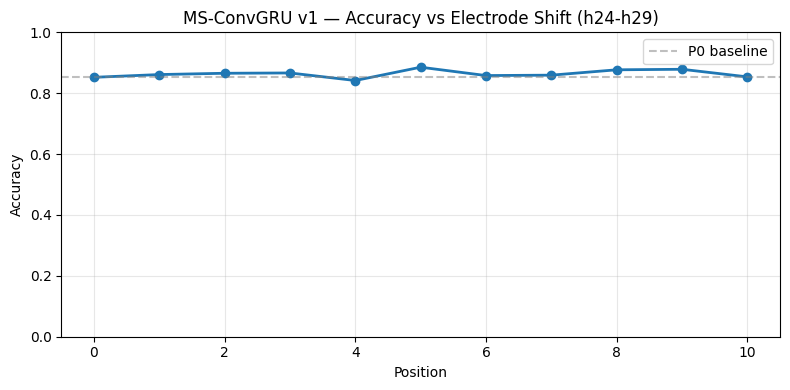

In [23]:
shift_subjects = [f"h{i}" for i in range(24, 30)]
shift_data = META[(META["subject"].isin(shift_subjects)) & (META["session"] == 0)]

s7_acc = {}
for pos in sorted(shift_data["position"].unique()):
    pos_df = shift_data[shift_data["position"] == pos]
    X_p, y_p, _ = load_and_norm(pos_df, stats=norm_stats)
    s7_acc[pos] = accuracy_score(y_p, base_predict(X_p))
    print(f"  Position {pos:2d}: {s7_acc[pos]:.4f}")

baseline = s7_acc.get(0, 0)
avg_shifted = np.mean([s7_acc[p] for p in s7_acc if p > 0])
print(f"\nP0 baseline: {baseline:.4f}, Avg shifted: {avg_shifted:.4f}, "
      f"Degradation: {(baseline - avg_shifted) * 100:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(list(s7_acc.keys()), list(s7_acc.values()), "o-", linewidth=2)
plt.axhline(y=baseline, color="gray", linestyle="--", alpha=0.5, label="P0 baseline")
plt.xlabel("Position")
plt.ylabel("Accuracy")
plt.title("MS-ConvGRU v1 — Accuracy vs Electrode Shift (h24-h29)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "msgru_v1_shift_curve.png"), dpi=150)
plt.show()

## S8: Few-Shot Calibration Analysis

In [24]:
subset_s8 = META[(META["session"] == 0) & (META["subject"].isin(TEST_SUBJECTS))]

configs = [
    ("Zero-shot",        [],     False, 0),
    ("1 rep, p0 only",   [0],    True,  7),
    ("1 rep, all pos",   [0],    False, 77),
    ("2 rep, p0 only",   [0, 1], True,  14),
    ("2 rep, all pos",   [0, 1], False, 154),
]

s8_lr, s8_proto = {}, {}
for label, reps, p0_only, n_trials in configs:
    accs_lr, accs_proto = [], []
    for subj in TEST_SUBJECTS:
        sdf = subset_s8[subset_s8["subject"] == subj]
        if len(reps) == 0:
            X_t, y_t, _ = load_and_norm(sdf, stats=norm_stats)
            accs_lr.append(accuracy_score(y_t, base_predict(X_t)))
            accs_proto.append(accs_lr[-1])
            continue
        if p0_only:
            cal_df = sdf[(sdf["repetition"].isin(reps)) & (sdf["position"] == 0)]
        else:
            cal_df = sdf[sdf["repetition"].isin(reps)]
        te_df = sdf[sdf["repetition"] == 2]
        if len(cal_df) == 0 or len(te_df) == 0:
            continue
        X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
        X_t, y_t, _ = load_and_norm(te_df, stats=norm_stats)

        ft_lr = logreg_finetune(X_c, y_c)
        accs_lr.append(accuracy_score(y_t, ft_lr(X_t)))

        ft_proto = prototype_finetune(X_c, y_c)
        accs_proto.append(accuracy_score(y_t, ft_proto(X_t)))

    s8_lr[label] = np.mean(accs_lr) if accs_lr else float("nan")
    s8_proto[label] = np.mean(accs_proto) if accs_proto else float("nan")
    print(f"  {label:20s}: LR={s8_lr[label]:.4f}  Proto={s8_proto[label]:.4f}  (~{n_trials} trials)")

  Zero-shot           : LR=0.5641  Proto=0.5641  (~0 trials)
  1 rep, p0 only      : LR=0.2835  Proto=0.2921  (~7 trials)
  1 rep, all pos      : LR=0.8133  Proto=0.6242  (~77 trials)
  2 rep, p0 only      : LR=0.3028  Proto=0.3074  (~14 trials)
  2 rep, all pos      : LR=0.8511  Proto=0.6609  (~154 trials)


## Latency

In [25]:
sample = X_train[:1]

def single_predict(x):
    t = torch.FloatTensor(x).to(DEVICE)
    with torch.no_grad():
        return model(t).argmax(1).cpu().numpy()

latency = measure_latency(single_predict, sample, n_runs=500)
print_latency(latency, model_name="MS-ConvGRU v1")


Latency — MS-ConvGRU v1
  Mean:   8.74 ms
  Median: 8.50 ms
  P95:    8.91 ms
  <300ms: ✓


## Summary

In [26]:
print()
print("=" * 75)
print("  MS-ConvGRU v1 -- RESULTS")
print("=" * 75)
print(f"{'Scenario':<25s} {'Zero-shot':>10s} {'Cal(LR)':>10s} {'Cal(Proto)':>12s}")
print("-" * 75)
for s in ["S1", "S2", "S3", "S4", "S5"]:
    zs = zero_results.get(s, 0)
    clr = cal_results_lr.get(s, 0)
    cpr = cal_results_proto.get(s, 0)
    print(f"{s:<25s} {zs*100:>9.2f}% {clr*100:>9.2f}% {cpr*100:>11.2f}%")
print(f"{'S6 Combined':<25s} {s6_zs*100:>9.2f}% {s6_cal*100:>9.2f}% {s6_cal_p*100:>11.2f}%")
print(f"{'S7 Gradual (avg shift)':<25s} {avg_shifted*100:>9.2f}% {'--':>10s} {'--':>12s}")
print("-" * 75)
print("S8 Few-Shot Calibration:")
for label in ['1 rep, p0 only', '1 rep, all pos', '2 rep, p0 only', '2 rep, all pos']:
    print(f"  {label:20s}: LR={s8_lr[label]*100:>7.2f}%  Proto={s8_proto[label]*100:>7.2f}%")
print("-" * 75)
print(f"Parameters:  {total_params:,}")
print(f"Latency p95: {latency['p95_ms']:.2f} ms")
print("=" * 75)


  MS-ConvGRU v1 -- RESULTS
Scenario                   Zero-shot    Cal(LR)   Cal(Proto)
---------------------------------------------------------------------------
S1                            61.37%     79.37%       75.66%
S2                            55.93%     80.86%       64.39%
S3                            56.42%     81.81%       63.96%
S4                            68.97%     83.90%       72.06%
S5                            82.78%     85.14%       75.82%
S6 Combined                   55.93%     86.25%       65.39%
S7 Gradual (avg shift)        86.47%         --           --
---------------------------------------------------------------------------
S8 Few-Shot Calibration:
  1 rep, p0 only      : LR=  28.35%  Proto=  29.21%
  1 rep, all pos      : LR=  81.33%  Proto=  62.42%
  2 rep, p0 only      : LR=  30.28%  Proto=  30.74%
  2 rep, all pos      : LR=  85.11%  Proto=  66.09%
---------------------------------------------------------------------------
Parameters:  125,059
La

## Comparison: LogReg vs Prototype Network Calibration

In [27]:
print()
print("=" * 65)
print("  CALIBRATION METHOD COMPARISON (on MS-ConvGRU)")
print("=" * 65)
print(f"{'Scenario':<15s} {'LogReg':>12s} {'Prototype':>12s} {'Diff':>10s} {'Winner':>10s}")
print("-" * 65)
for s in ["S1", "S2", "S3", "S4", "S5"]:
    lr = cal_results_lr.get(s, 0) * 100
    pr = cal_results_proto.get(s, 0) * 100
    diff = pr - lr
    winner = "Proto" if diff > 0 else "LogReg" if diff < 0 else "Tie"
    print(f"{s:<15s} {lr:>11.2f}% {pr:>11.2f}% {diff:>+9.2f}% {winner:>10s}")

lr_s6 = s6_cal * 100
pr_s6 = s6_cal_p * 100
diff_s6 = pr_s6 - lr_s6
winner_s6 = "Proto" if diff_s6 > 0 else "LogReg" if diff_s6 < 0 else "Tie"
print(f"{'S6':<15s} {lr_s6:>11.2f}% {pr_s6:>11.2f}% {diff_s6:>+9.2f}% {winner_s6:>10s}")
print("=" * 65)


  CALIBRATION METHOD COMPARISON (on MS-ConvGRU)
Scenario              LogReg    Prototype       Diff     Winner
-----------------------------------------------------------------
S1                    79.37%       75.66%     -3.71%     LogReg
S2                    80.86%       64.39%    -16.47%     LogReg
S3                    81.81%       63.96%    -17.86%     LogReg
S4                    83.90%       72.06%    -11.84%     LogReg
S5                    85.14%       75.82%     -9.33%     LogReg
S6                    86.25%       65.39%    -20.86%     LogReg


## Save

In [28]:
print("Model saved at:", MODELS_DIR / "msgru_v1.pt")
print("Done.")

Model saved at: /Users/erdiantiwigaputriandini/Documents/Kuliah/Tugas Akhir/04. TA/02. Code/Tugas-Akhir/results/models/msgru_v1.pt
Done.
